In [19]:

import stpsf
import warnings

import astropy.units as u
import FunctionLib as FL
import inspect
from tqdm import tqdm
import astropy
import wave
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from collections import defaultdict
import re
import scipy
from astropy.io import fits as asfits

mpl.rcParams['font.family'] = 'serif'


warnings.filterwarnings("ignore")

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(os.path.expanduser(
    './DJAV4.2Catalog.pkl'))
print(DJAv4Catalog.sample_num())

DJAv4Catalog.to_dataframe()

537


,survey_id_subid,prism_filepath,prism_redshift,determined_redshift,grating_filepaths,grating_redshifts,file_count,available_filters,properties,survey_id,sample_flag,reason_for_exclusion,grating_slitloss_correction,grating_within_coverage,lines_fit,s3fit_result_path,line_ratios
0,snh0pe-v4_4446_102,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.2259,0.2259,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",3,"{g235m-f170lp, g140m-f100lp, prism-clear}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{}
1,snh0pe-v4_4446_143,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.6318,1.6311,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.6313, 'g235m-f170lp': 1.6309}",3,"{g235m-f170lp, g140m-f100lp, prism-clear}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{}
2,snh0pe-v4_4446_285,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.4446,0.4462,{'g235m-f170lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g235m-f170lp': 0.4462, 'g140m-f100lp': 0.4462}",3,"{g235m-f170lp, g140m-f100lp, prism-clear}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{}
3,snh0pe-v4_4446_29,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7834,1.77975,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7799, 'g235m-f170lp': 1.7796}",3,"{g235m-f170lp, g140m-f100lp, prism-clear}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{}
4,snh0pe-v4_4446_123,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7855,1.7855,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7855, 'g235m-f170lp': 1.7851}",3,"{g235m-f170lp, g140m-f100lp, prism-clear}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43037,glimpse-obs02-v4_9223_9152,None,None,5.5385,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 5.5385},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{},{},None,{}
43038,glimpse-obs02-v4_9223_98001,None,None,2.6322,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 2.6322},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{},{},None,{}
43039,glimpse-obs02-v4_9223_47046,None,None,4.3554,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 4.3554},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{},{},None,{}
43040,glimpse-obs02-v4_9223_45350,None,None,1.3675,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 1.3675},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{},{},None,{}


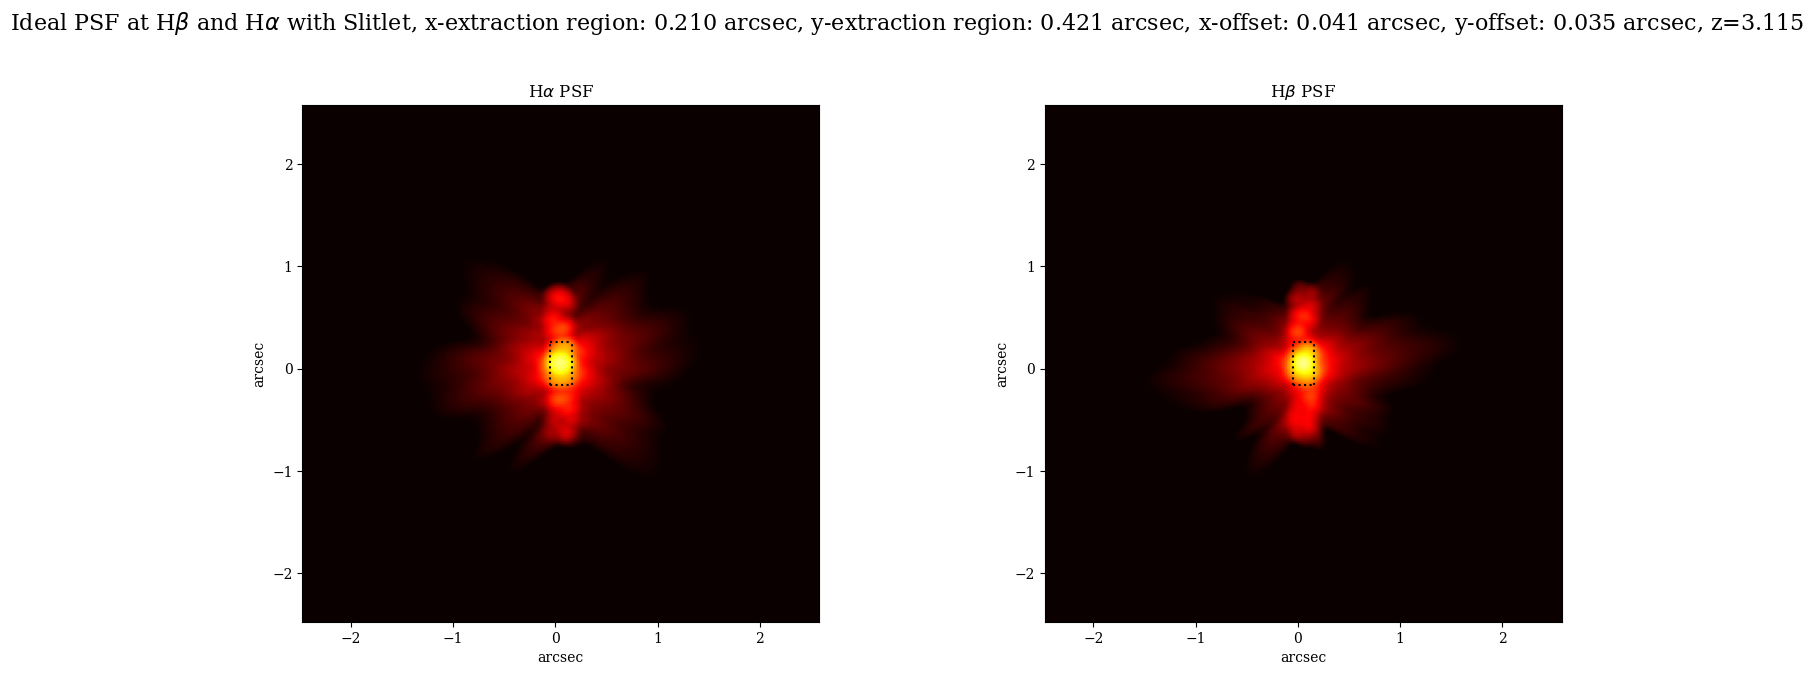

H-alpha fraction: 0.9108218283069909
H-beta fraction: 0.9283600460303012


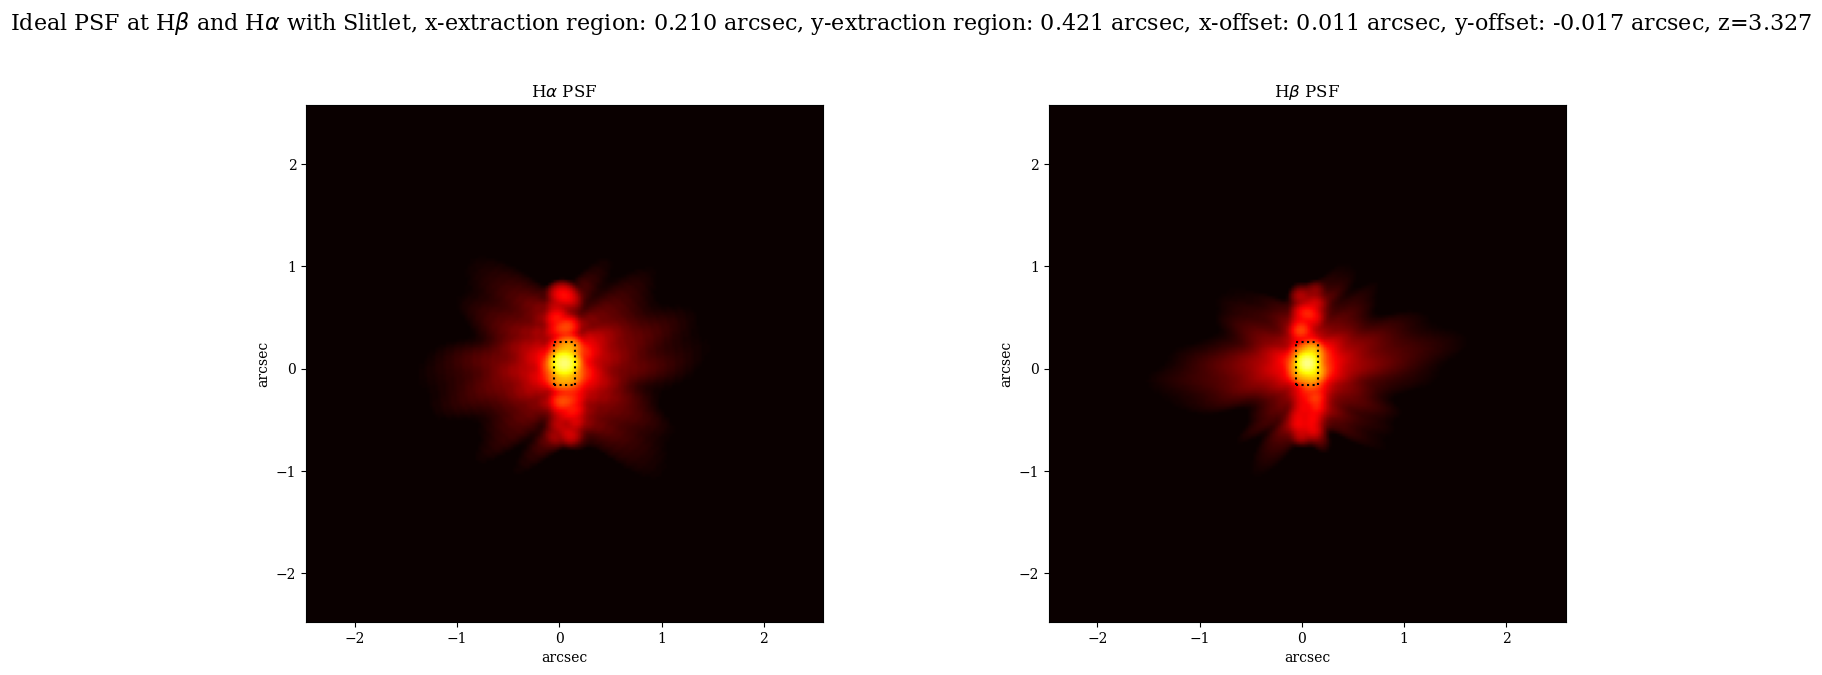

H-alpha fraction: 0.9021673231198751
H-beta fraction: 0.9233112310428625


KeyboardInterrupt: 

In [30]:
x_offset_list = []
y_offset_list = []

for survey_id_subid, entry in DJAv4Catalog.catalog_iterator(20):

    prism_filepath=entry['prism_filepath']
    redshift=entry['prism_redshift']
    if prism_filepath is None:
        continue
    for filter_key, path in entry['grating_within_coverage'].items():


        with asfits.open(path) as hdul:

            x_offset=hdul[1].header['SRCXPOS']
            x_offset_list.append(x_offset*0.20)

            y_offset=hdul[1].header['SRCYPOS']
            y_offset_list.append(y_offset*0.46)
            # print(f'status: {hdul[1].header["SHUTSTA"]}')
            # if hdul[1].header["SHUTSTA"] == '1x1':
            #     continue


            nirspec = stpsf.NIRSpec()
            # nirspec.options['source_offset_x'] = x_offset*0.20
            # nirspec.options['source_offset_y'] = y_offset*0.46
            nirspec.filter = 'F170LP'


            nirspec.image_mask='Three adjacent MSA open shutters'

            wavelength1_A = 4863 * u.AA*(1+redshift)
            wavelength2_A = 6563 * u.AA*(1+redshift)
            wavelength1_m = wavelength1_A.to(u.m).value
            wavelength2_m = wavelength2_A.to(u.m).value

            selection_mask = np.zeros((48,48), dtype=bool)
            x1, x2 = 23, 25
            y1, y2 = 22, 26
            selection_mask[y1:y2, x1:x2] = True

            OVERSAMPLE = 4

            hbeta_psf = nirspec.calc_psf(monochromatic=wavelength1_m, oversample=OVERSAMPLE)
            halpha_psf = nirspec.calc_psf(monochromatic=wavelength2_m, oversample=OVERSAMPLE)

            pix_scale = 0.10532787  # arcsec / pixel

            # 2. 获取图像数据的形状（以像素为单位）
            # 假设 H-beta 和 H-alpha 的图像尺寸相同
            data = hbeta_psf[3].data
            ny, nx = data.shape
            center_x, center_y = nx / 2 - 0.5, ny / 2 - 0.5

            # 3. 计算图像的范围（以角秒为单位），并将中心设为 (0,0)
            # extent = [x_min, x_max, y_min, y_max]
            extent_arcsec = [
                (0 - center_x) * pix_scale,
                (nx - center_x) * pix_scale,
                (0 - center_y) * pix_scale,
                (ny - center_y) * pix_scale
            ]

            # 4. 转换虚线框的像素坐标为角秒坐标
            x1_arcsec = (x1 - center_x) * pix_scale
            x2_arcsec = (x2 - center_x) * pix_scale
            y1_arcsec = (y1 - center_y) * pix_scale
            y2_arcsec = (y2 - center_y) * pix_scale

            # --- 绘图代码 ---

            fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(15, 7))

            vmax = max(hbeta_psf[3].data.max(), halpha_psf[3].data.max())
            vmin = vmax / 1e10
            norm = LogNorm(vmin=vmin*1e4, vmax=vmax)

            # 绘制 H-beta PSF
            # 使用 extent 参数来设置坐标轴
            ax1.imshow(hbeta_psf[2].data, origin='lower', cmap='hot', norm=norm, extent=extent_arcsec)
            #ax1.imshow(selection_mask, origin='lower', cmap='gray', alpha=0.5, extent=extent_arcsec)
            ax1.set_title(r'H$\beta$ PSF')
            ax1.vlines([x1_arcsec, x2_arcsec], y1_arcsec, y2_arcsec, colors='k', linestyles='dotted')
            ax1.hlines([y1_arcsec, y2_arcsec], x1_arcsec, x2_arcsec, colors='k', linestyles='dotted')
            ax1.set_xlabel("arcsec")
            ax1.set_ylabel("arcsec")

            # 绘制 H-alpha PSF
            ax2.imshow(halpha_psf[2].data, origin='lower', cmap='hot', norm=norm, extent=extent_arcsec)

            #ax2.imshow(selection_mask, origin='lower', cmap='gray', alpha=0.5, extent=extent_arcsec)
            ax2.set_title(r'H$\alpha$ PSF')
            ax2.vlines([x1_arcsec, x2_arcsec], y1_arcsec, y2_arcsec, colors='k', linestyles='dotted')
            ax2.hlines([y1_arcsec, y2_arcsec], x1_arcsec, x2_arcsec, colors='k', linestyles='dotted')
            ax2.set_xlabel("arcsec")
            ax2.set_ylabel("arcsec")


            plt.suptitle(f'Ideal PSF at H$\\beta$ and H$\\alpha$ with Slitlet, x-extraction region: 0.210 arcsec, y-extraction region: 0.421 arcsec, x-offset: {x_offset*0.20:.3f} arcsec, y-offset: {y_offset*0.46:.3f} arcsec, z={redshift:.3f}', fontsize=16)
            # 优化布局以防止标题和标签重叠
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()



            alpha_data=halpha_psf[3].data
            selected_flux_alpha = alpha_data[selection_mask]
            fraction=selected_flux_alpha.sum() / alpha_data.sum()
            print(f'H-alpha fraction: {fraction}')

            beta_data=hbeta_psf[3].data
            selected_flux_beta = beta_data[selection_mask]
            fraction=selected_flux_beta.sum() / beta_data.sum()
            print(f'H-beta fraction: {fraction}')


In [31]:
hdul.info()

Filename: /home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_g235m-f170lp_4446_274.spec.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  SPEC1D        1 BinTableHDU    368   3685R x 9C   [D, D, D, D, D, D, D, D, D]   


In [32]:
hdul[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   72 / length of dimension 1                          
NAXIS2  =                 3685 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    9 / number of table fields                         
VERSION = '0.9.5.dev2+g80b81b4' / msaexp software version                       
TOMUJY  =                  1.0 / Conversion from pixel values to microJansky    
PROFCEN = 0.000999999999987487 / PRF profile center                             
PROFSIG =  0.24610568072308747 / PRF profile sigma                              
PROFSTRT=                   

In [14]:
calculate_halpha_hbeta_psf_for_given_catalog('goodsn-wide2-v4_1211_2250', DJAv4Catalog.catalog['goodsn-wide2-v4_1211_2250'])

ID: goodsn-wide2-v4_1211_2250, Filter: f170lp, H-alpha PSF fraction: 0.18242280182149856, H-beta PSF fraction: 0.14882480559544864


1

In [2]:
catalog=DJAv4Catalog.catalog['stark-rxcj2248-v4_2478_3']
for filter, grating_filepath in catalog['grating_filepaths'].items():


    filter_name=filter.split('-')[1]
    halpha_wavelength = 6564.61 * (1 + catalog['determined_redshift']) * u.AA
    hbeta_wavelength = 4862.68 * (1 + catalog['determined_redshift']) * u.AA


    with asfits.open(grating_filepath) as grating_spectrum_fits:
        x_offset_grating = grating_spectrum_fits[1].header.get('SRCXPOS',0.0)
        y_offset_grating = grating_spectrum_fits[1].header.get('SRCYPOS',0.0)
        slitlit_status=grating_spectrum_fits[1].header.get('SHUTSTA','')

        print(f"x:{x_offset_grating}, y:{y_offset_grating}, slitlit:{slitlit_status}")



        nirspec= stpsf.NIRSpec()
        nirspec.options['source_offset_x']= x_offset_grating*0.20
        nirspec.options['source_offset_y']= y_offset_grating*0.46

        nirspec.filter=filter_name
        nirspec.image_mask='Three adjacent MSA open shutters'

        halpha_wavelength=halpha_wavelength.to(u.m).value
        hbeta_wavelength=hbeta_wavelength.to(u.m).value

        selection_mask=np.zeros((48,48),dtype=bool)
        if slitlit_status=='1x1':
            x1,x2=23,25
            y1,y2=22,26
        elif slitlit_status=='x11':
            x1,x2=23,25
            y1,y2=22,26
        elif slitlit_status=='11x':
            x1,x2=23,25
            y1,y2=22,26

        selection_mask[y1:y2,x1:x2]=True

        OVERSAMPLE=4

        halpha_psf_fun=nirspec.calc_psf(monochromatic=halpha_wavelength,oversample=OVERSAMPLE)
        hbeta_psf=nirspec.calc_psf(monochromatic=hbeta_wavelength,oversample=OVERSAMPLE)

        halpha_selection_flux=halpha_psf_fun[3].data[selection_mask]
        hbeta_selection_flux=hbeta_psf[3].data[selection_mask]

        halpha_total_flux=np.nansum(halpha_psf_fun[3].data)
        hbeta_total_flux=np.nansum(hbeta_psf[3].data)

        halpha_psf_fraction=np.nansum(halpha_selection_flux)/halpha_total_flux
        hbeta_psf_fraction=np.nansum(hbeta_selection_flux)/hbeta_total_flux

        print(f'ID: {id}, Filter: {filter_name}, H-alpha PSF fraction: {halpha_psf_fraction}, H-beta PSF fraction: {hbeta_psf_fraction}')

x:-0.06499999761581421, y:-0.2919999957084656, slitlit:1x1
ID: <built-in function id>, Filter: f170lp, H-alpha PSF fraction: 0.6944385563779657, H-beta PSF fraction: 0.7807816559201395
x:-0.06499999761581421, y:-0.2919999957084656, slitlit:1x1
ID: <built-in function id>, Filter: f100lp, H-alpha PSF fraction: 0.6944385563779657, H-beta PSF fraction: 0.7807816559201395
x:-0.06499999761581421, y:-0.2919999957084656, slitlit:1x1
ID: <built-in function id>, Filter: f290lp, H-alpha PSF fraction: 0.6944385563779657, H-beta PSF fraction: 0.7807816559201395


In [3]:
0.78/0.69

1.1304347826086958

In [4]:
catalog['determined_redshift']

<Quantity 6.1052>

In [4]:
x_offset_list = []
y_offset_list = []

for survey_id_subid, entry in DJAv4Catalog.catalog_iterator():

    prism_filepath=entry['prism_filepath']
    redshift=entry['prism_redshift']
    if prism_filepath is None:
        continue
    for filter_key, path in entry['grating_within_coverage'].items():


        with asfits.open(path) as hdul:

            x_offset=hdul[1].header['SRCXPOS']
            x_offset_list.append(x_offset*0.20)

            y_offset=hdul[1].header['SRCYPOS']
            y_offset_list.append(y_offset*0.46)

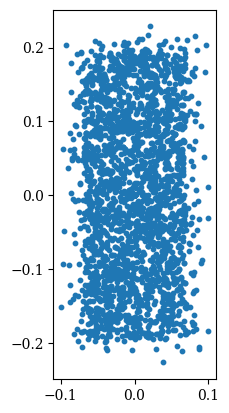

In [8]:
plt.scatter(x_offset_list, y_offset_list,s=10)
plt.gca().set_aspect('equal', adjustable='box')

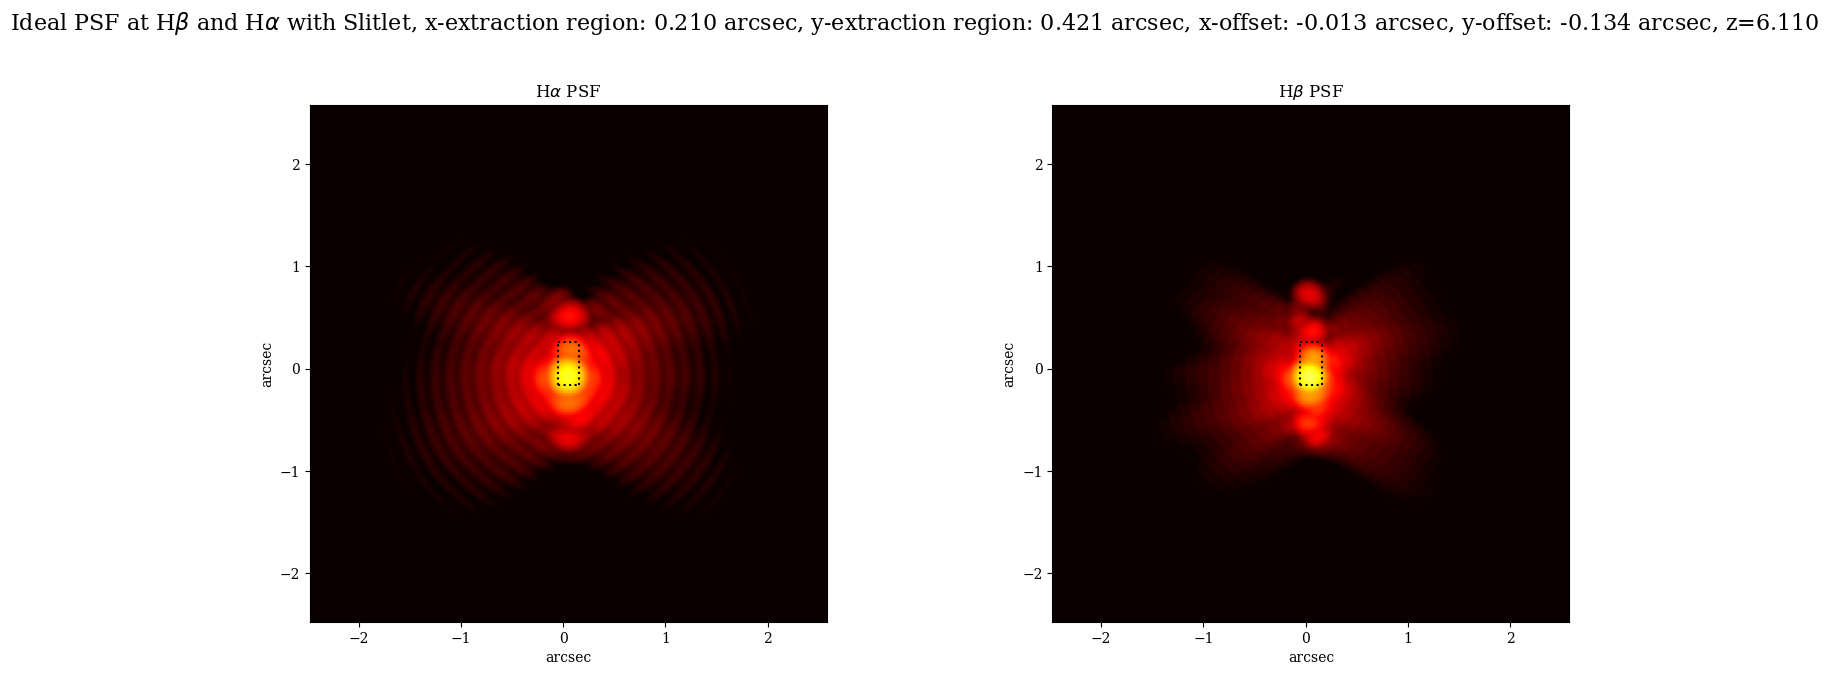

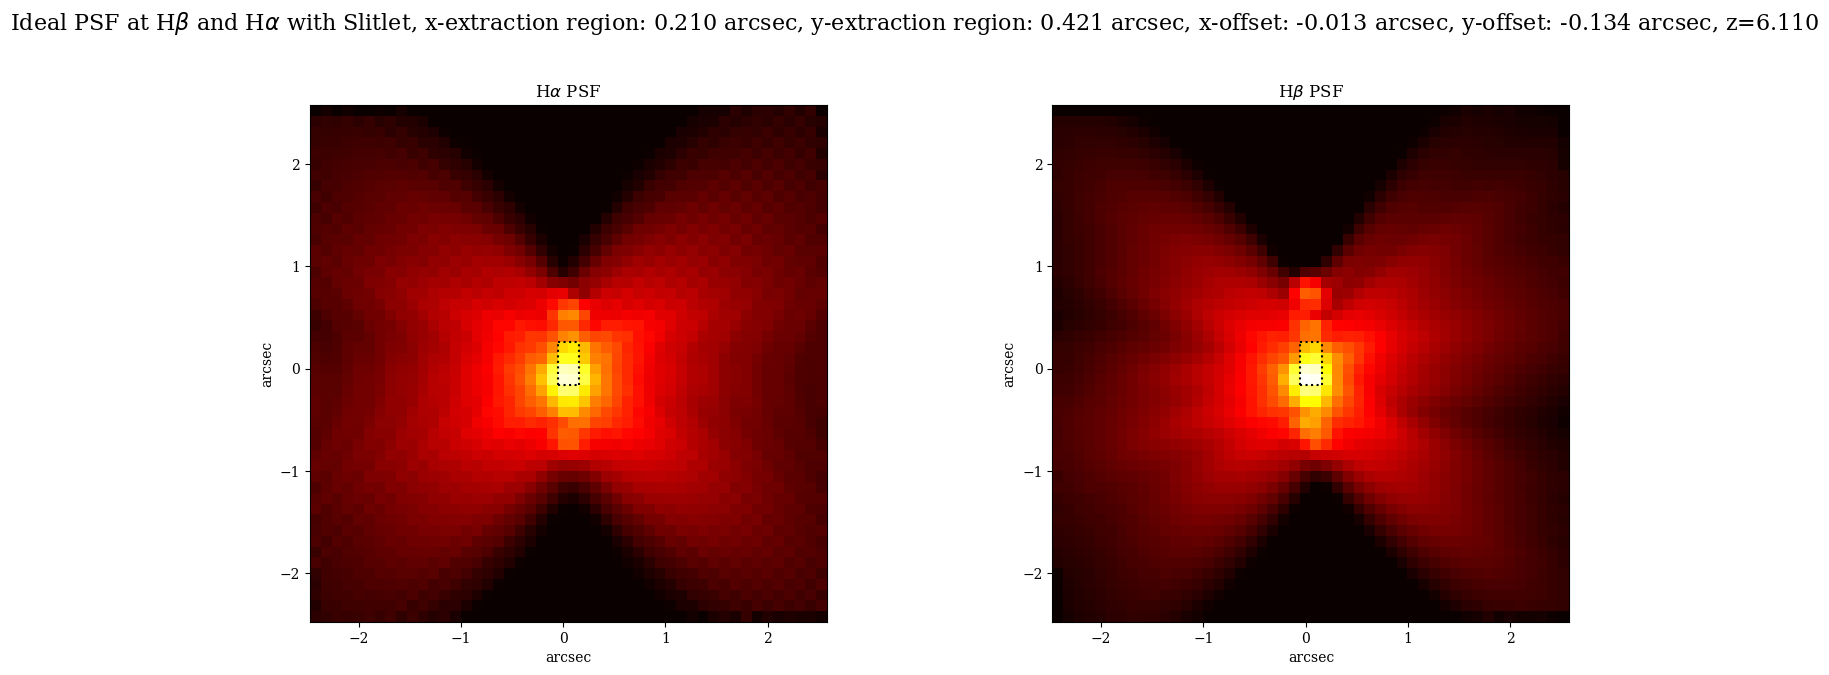

H-alpha fraction: 0.6942484985318987， H-beta fraction: 0.7805778460303837


In [21]:


x_offset=-0.065*0.20

y_offset=-0.292*0.46

redshift=6.11

nirspec = stpsf.NIRSpec()
nirspec.options['source_offset_x'] = x_offset
nirspec.options['source_offset_y'] = y_offset
nirspec.filter = 'F290LP'


nirspec.image_mask='Three adjacent MSA open shutters'

wavelength1_A = 4863 * u.AA*(1+redshift)
wavelength2_A = 6563 * u.AA*(1+redshift)
wavelength1_m = wavelength1_A.to(u.m).value
wavelength2_m = wavelength2_A.to(u.m).value

selection_mask = np.zeros((48,48), dtype=bool)
x1, x2 = 23, 25
y1, y2 = 22, 26
selection_mask[y1:y2, x1:x2] = True

OVERSAMPLE = 4

hbeta_psf = nirspec.calc_psf(monochromatic=wavelength1_m, oversample=OVERSAMPLE)
halpha_psf = nirspec.calc_psf(monochromatic=wavelength2_m, oversample=OVERSAMPLE)

pix_scale = 0.10532787  # arcsec / pixel

# 2. 获取图像数据的形状（以像素为单位）
# 假设 H-beta 和 H-alpha 的图像尺寸相同
data = hbeta_psf[3].data
ny, nx = data.shape
center_x, center_y = nx / 2 - 0.5, ny / 2 - 0.5

# 3. 计算图像的范围（以角秒为单位），并将中心设为 (0,0)
# extent = [x_min, x_max, y_min, y_max]
extent_arcsec = [
    (0 - center_x) * pix_scale,
    (nx - center_x) * pix_scale,
    (0 - center_y) * pix_scale,
    (ny - center_y) * pix_scale
]

# 4. 转换虚线框的像素坐标为角秒坐标
x1_arcsec = (x1 - center_x) * pix_scale
x2_arcsec = (x2 - center_x) * pix_scale
y1_arcsec = (y1 - center_y) * pix_scale
y2_arcsec = (y2 - center_y) * pix_scale

# --- 绘图代码 ---

fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(15, 7))

vmax = max(hbeta_psf[3].data.max(), halpha_psf[3].data.max())
vmin = vmax / 1e10
norm = LogNorm(vmin=vmin*1e4, vmax=vmax)

# 绘制 H-beta PSF
# 使用 extent 参数来设置坐标轴
ax1.imshow(hbeta_psf[2].data, origin='lower', cmap='hot', norm=norm, extent=extent_arcsec)
#ax1.imshow(selection_mask, origin='lower', cmap='gray', alpha=0.5, extent=extent_arcsec)
ax1.set_title(r'H$\beta$ PSF')
ax1.vlines([x1_arcsec, x2_arcsec], y1_arcsec, y2_arcsec, colors='k', linestyles='dotted')
ax1.hlines([y1_arcsec, y2_arcsec], x1_arcsec, x2_arcsec, colors='k', linestyles='dotted')
ax1.set_xlabel("arcsec")
ax1.set_ylabel("arcsec")

# 绘制 H-alpha PSF
ax2.imshow(halpha_psf[2].data, origin='lower', cmap='hot', norm=norm, extent=extent_arcsec)

#ax2.imshow(selection_mask, origin='lower', cmap='gray', alpha=0.5, extent=extent_arcsec)
ax2.set_title(r'H$\alpha$ PSF')
ax2.vlines([x1_arcsec, x2_arcsec], y1_arcsec, y2_arcsec, colors='k', linestyles='dotted')
ax2.hlines([y1_arcsec, y2_arcsec], x1_arcsec, x2_arcsec, colors='k', linestyles='dotted')
ax2.set_xlabel("arcsec")
ax2.set_ylabel("arcsec")


plt.suptitle(f'Ideal PSF at H$\\beta$ and H$\\alpha$ with Slitlet, x-extraction region: 0.210 arcsec, y-extraction region: 0.421 arcsec, x-offset: {x_offset:.3f} arcsec, y-offset: {y_offset:.3f} arcsec, z={redshift:.3f}', fontsize=16)
# 优化布局以防止标题和标签重叠
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(15, 7))

vmax = max(hbeta_psf[3].data.max(), halpha_psf[3].data.max())
vmin = vmax / 1e10
norm = LogNorm(vmin=vmin*1e4, vmax=vmax)

# 绘制 H-beta PSF
# 使用 extent 参数来设置坐标轴
ax1.imshow(hbeta_psf[3].data, origin='lower', cmap='hot', norm=norm, extent=extent_arcsec)
#ax1.imshow(selection_mask, origin='lower', cmap='gray', alpha=0.5, extent=extent_arcsec)
ax1.set_title(r'H$\beta$ PSF')
ax1.vlines([x1_arcsec, x2_arcsec], y1_arcsec, y2_arcsec, colors='k', linestyles='dotted')
ax1.hlines([y1_arcsec, y2_arcsec], x1_arcsec, x2_arcsec, colors='k', linestyles='dotted')
ax1.set_xlabel("arcsec")
ax1.set_ylabel("arcsec")

# 绘制 H-alpha PSF
ax2.imshow(halpha_psf[3].data, origin='lower', cmap='hot', norm=norm, extent=extent_arcsec)

#ax2.imshow(selection_mask, origin='lower', cmap='gray', alpha=0.5, extent=extent_arcsec)
ax2.set_title(r'H$\alpha$ PSF')
ax2.vlines([x1_arcsec, x2_arcsec], y1_arcsec, y2_arcsec, colors='k', linestyles='dotted')
ax2.hlines([y1_arcsec, y2_arcsec], x1_arcsec, x2_arcsec, colors='k', linestyles='dotted')
ax2.set_xlabel("arcsec")
ax2.set_ylabel("arcsec")


plt.suptitle(f'Ideal PSF at H$\\beta$ and H$\\alpha$ with Slitlet, x-extraction region: 0.210 arcsec, y-extraction region: 0.421 arcsec, x-offset: {x_offset:.3f} arcsec, y-offset: {y_offset:.3f} arcsec, z={redshift:.3f}', fontsize=16)
# 优化布局以防止标题和标签重叠
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


alpha_data=halpha_psf[3].data
selected_flux_alpha = alpha_data[selection_mask]
alpha_fraction=selected_flux_alpha.sum() / alpha_data.sum()


beta_data=hbeta_psf[3].data
selected_flux_beta = beta_data[selection_mask]
beta_fraction=selected_flux_beta.sum() / beta_data.sum()
print(f'H-alpha fraction: {alpha_fraction}， H-beta fraction: {beta_fraction}')

In [26]:
for subid, catalog in DJAv4Catalog.catalog_iterator():

    if not catalog['sample_flag']:
        continue

    for filter, grating_filepath in catalog['grating_filepaths'].items():
        with asfits.open(grating_filepath) as grating_spectrum_fits:
            hdul=grating_spectrum_fits



In [15]:
plt.figure(figsize=(8, 12))
nirspec = stpsf.NIRSpec()

nirspec.image_mask='Three adjacent MSA open shutters'
wavelength1_A = 4863 * u.AA*(1+0)
hbeta_psf = nirspec.calc_psf(monochromatic=wavelength1_A, oversample=8)

<Figure size 800x1200 with 0 Axes>

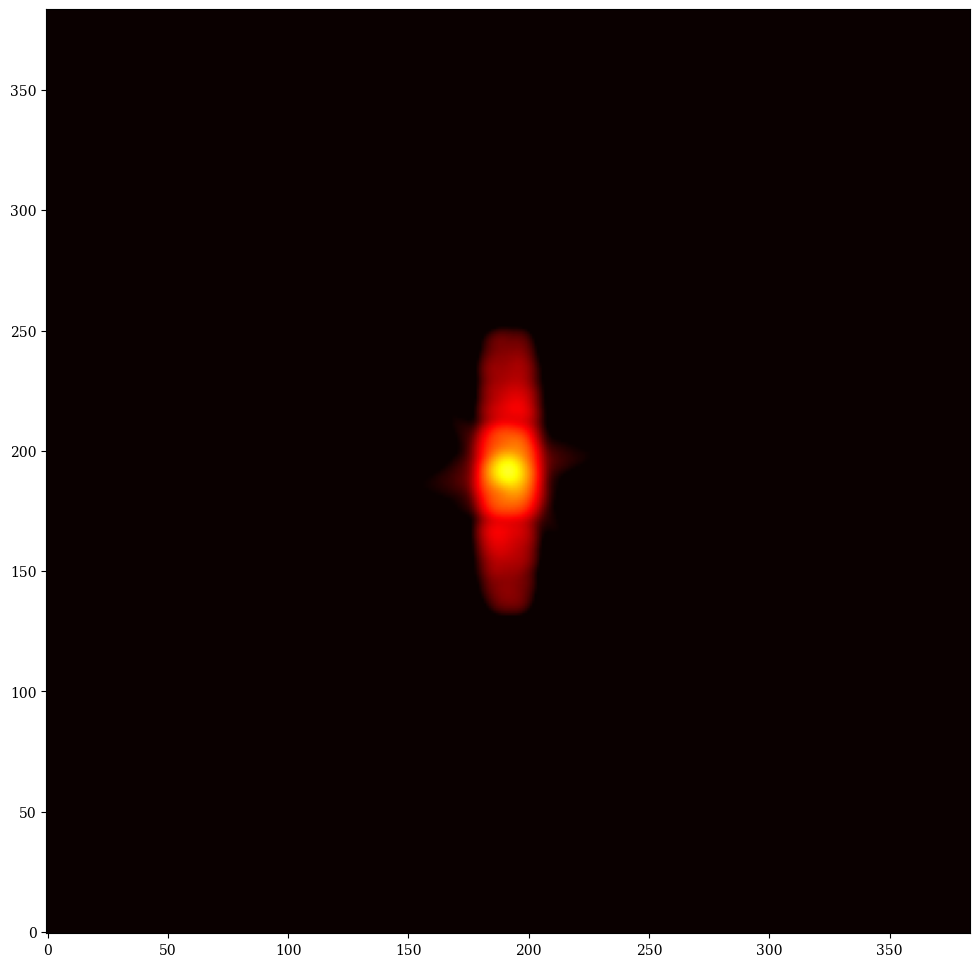

In [16]:
fig, ax=plt.subplots(1, 1, figsize=(12, 12))
vmax = hbeta_psf[3].data.max()
vmin = vmax / 1e10
norm = LogNorm(vmin=vmin*1e4, vmax=vmax)

ax.imshow(hbeta_psf[2].data, origin='lower', cmap='hot', norm=norm)

In [18]:
hbeta_psf.info()

Filename: (No file associated with this HDUList)
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  OVERSAMP      1 PrimaryHDU     115   (384, 384)   float64   
  1  DET_SAMP      1 ImageHDU       117   (48, 48)   float64   
  2  OVERDIST      1 ImageHDU       164   (384, 384)   float64   
  3  DET_DIST      1 ImageHDU       165   (48, 48)   float64   
